In [1]:
import sys
import os

# Paths
PROJECT_ROOT = os.path.abspath("../..")
PHASE2_PATH  = os.path.abspath("..")

sys.path.append(PROJECT_ROOT)
sys.path.append(PHASE2_PATH)

# Imports
import importlib
import insurance_risk_engine
import insurance_risk_engine.visualizations as viz
import insurance_risk_engine.reserving as reserving 

# Insurance Risk Engine — Full Analysis
*Python Phase Portfolio Project — Actuarial Analyst Target*

This notebook answers five business questions about an insurance
portfolio using the Collective Risk Model:
S = X1 + X2 + ... + Xn  where  N ~ Poisson(500),  Xi ~ Lognormal

1. **Is this portfolio profitable?**
2. **How risky is it under normal conditions?**
3. **What happens under stress scenarios?**
4. **How likely is an extreme loss event?**
5. **Is the company holding sufficient capital?**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from insurance_risk_engine.inputs import PORTFOLIO, SIMULATION
from insurance_risk_engine.deterministic_model import run_deterministic_model
from insurance_risk_engine.stochastic_model import run_monte_carlo
from insurance_risk_engine.risk_metrics import compute_risk_metrics
from insurance_risk_engine.optimization import (
    premium_for_breakeven, premium_for_target_ruin)
from insurance_risk_engine.visualizations import (
    plot_loss_distribution, plot_severity_comparison,
    plot_stress_scenarios, plot_summary_dashboard)

print(f"All imports successful")
print(f"Simulations per run: {SIMULATION['num_sims']:,}")
print(f"MC random seed:     {SIMULATION['random_seed_mc']}")
print(f"RI random seed:     {SIMULATION['random_seed_reinsurance']}")

All imports successful
Simulations per run: 100,000
MC random seed:     42
RI random seed:     99


## 1. Portfolio Assumptions

All assumptions live in `inputs.py`. Changing one value there
propagates automatically through every module. No hardcoded
numbers anywhere else in the codebase.

In [3]:
pd.DataFrame({
    "Assumption": [
        "Gross Written Premium", "Number of Policies",
        "Claim Frequency", "Mean Severity", "Severity CV",
        "Expense Ratio", "Reinsurance Cost Ratio",
        "XL Retention Limit", "Available Capital", "Management Buffer",
    ],
    "Value": [
        f"Rs {PORTFOLIO['gross_written_premium']/1e7:.0f} Cr",
        f"{PORTFOLIO['num_policies']:,}",
        f"{PORTFOLIO['claim_frequency']:.1%}",
        f"Rs {PORTFOLIO['mean_severity']:,}",
        f"{PORTFOLIO['severity_cv']:.1f}",
        f"{PORTFOLIO['expense_ratio']:.0%}",
        f"{PORTFOLIO['ri_cost_ratio']:.0%}",
        f"Rs {PORTFOLIO['xl_retention']:,}",
        f"Rs {PORTFOLIO['available_capital']/1e7:.0f} Cr",
        f"{PORTFOLIO['management_buffer']:.0%}",
    ],
    "Notes": [
        "Annual gross premium written", "In-force policy count",
        "Historical 5yr average", "Mean incurred loss per claim",
        "std/mean — 1.5 = high dispersion", "Operating expenses / GWP",
        "RI cession cost / GWP", "Per-occurrence XL attachment",
        "Surplus allocated to portfolio", "Buffer above minimum SCR",
    ],
}).style.hide(axis="index")

Assumption,Value,Notes
Gross Written Premium,Rs 10 Cr,Annual gross premium written
Number of Policies,"50,000",In-force policy count
Claim Frequency,1.0%,Historical 5yr average
Mean Severity,"Rs 120,000",Mean incurred loss per claim
Severity CV,1.5,std/mean — 1.5 = high dispersion
Expense Ratio,30%,Operating expenses / GWP
Reinsurance Cost Ratio,8%,RI cession cost / GWP
XL Retention Limit,"Rs 500,000",Per-occurrence XL attachment
Available Capital,Rs 2 Cr,Surplus allocated to portfolio
Management Buffer,20%,Buffer above minimum SCR


## 2. Deterministic Model

Replicates the Excel Calculations sheet under average conditions.
Verification targets: Claims = 500, Loss = Rs 6 Cr, CR = 98%.

In [4]:
det = run_deterministic_model()
pd.DataFrame({
    "Metric": [
        "Expected Claim Count", "Expected Gross Loss", "Expenses",
        "RI Cost", "Net Profit", "Loss Ratio", "Combined Ratio",
    ],
    "Value": [
        f"{det['expected_claim_count']:.0f}",
        f"Rs {det['expected_gross_loss']/1e7:.2f} Cr",
        f"Rs {det['expenses']/1e7:.2f} Cr",
        f"Rs {det['ri_cost']/1e7:.2f} Cr",
        f"Rs {det['net_profit']/1e7:.2f} Cr",
        f"{det['loss_ratio']:.1%}",
        f"{det['combined_ratio']:.1%}",
    ],
}).style.hide(axis="index")

Metric,Value
Expected Claim Count,500
Expected Gross Loss,Rs 6.00 Cr
Expenses,Rs 3.00 Cr
RI Cost,Rs 0.80 Cr
Net Profit,Rs 0.20 Cr
Loss Ratio,60.0%
Combined Ratio,98.0%


## 3. Why Python Extends Excel — Severity Distribution

**Excel model:** every claim costs exactly Rs 1,20,000 — constant
severity. Produces a narrow symmetric distribution. The reinsurance
treaty never triggers.

**Python model:** claims follow Lognormal(mean=Rs 1.2L, CV=1.5).
Most claims are small; occasionally one claim is 10x the average.
Result: wide right-skewed distribution, non-zero ruin probability,
meaningful reinsurance recovery in stress years.

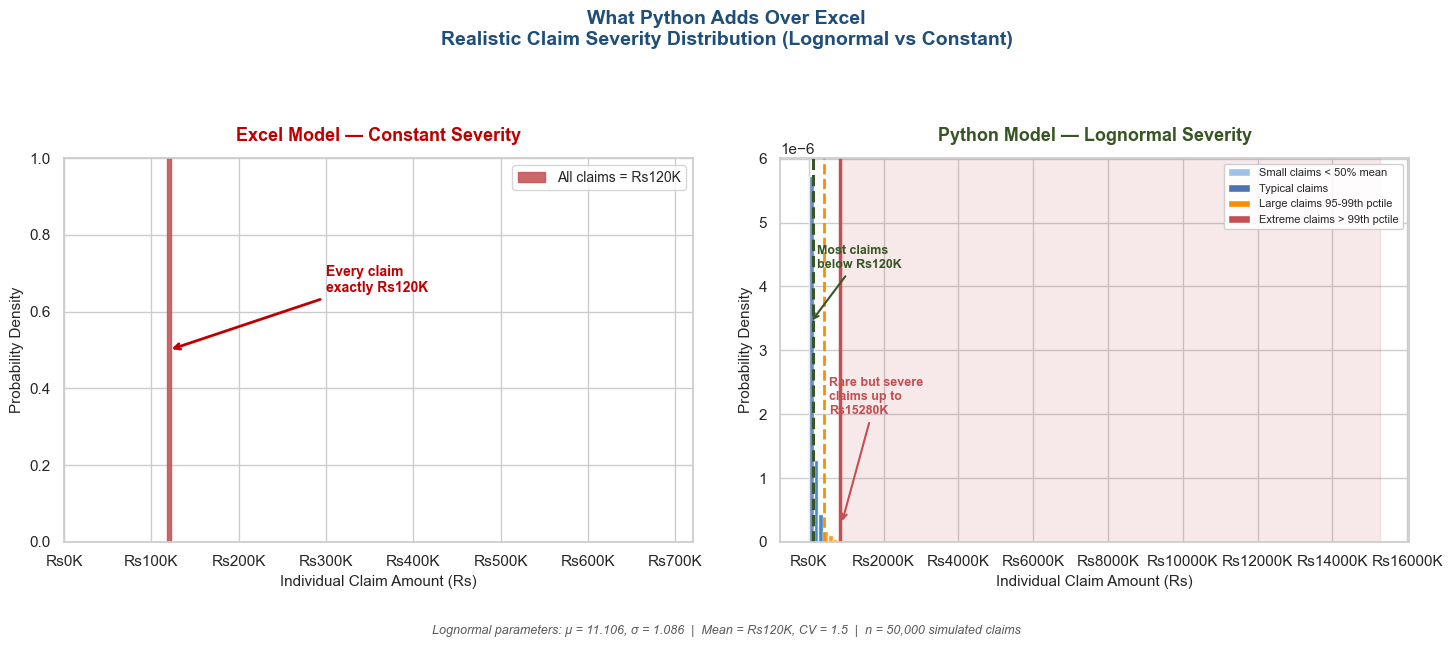

In [5]:
plot_severity_comparison(PORTFOLIO, save=True)

## 4. Monte Carlo Simulation — Collective Risk Model

**Model:** S = X1 + X2 + ... + Xn
- **N ~ Poisson(λ):**  claim count based on PORTFOLIO assumptions (inputs.py)
- **Xi ~ Lognormal(mu, sigma):** severity based on PORTFOLIO assumptions
- **100,000 simulated years**

Parameters are sourced from baseline portfolio assumptions for exposure and frequency.
Claim severity is calibrated using MLE-fitted Lognormal parameters estimated
from observed claims in the SQL database.

In [6]:
print("Running Monte Carlo simulation...")

from insurance_risk_engine.mle_analysis import run_mle_analysis
from insurance_risk_engine.stochastic_model import run_monte_carlo
from insurance_risk_engine.inputs import PORTFOLIO, SIMULATION

# Fit severity from database
mle = run_mle_analysis("../../phase3_sql/database/insurance_data.db")

# Baseline portfolio assumptions
mc_params = PORTFOLIO.copy()

# Override severity with fitted lognormal parameters
mc_params["mu"] = mle["mu"]
mc_params["sigma"] = mle["sigma"]

# Run simulation
losses, counts = run_monte_carlo(
    params=mc_params,
    sim_params=SIMULATION
)

skew = float(np.mean((losses - losses.mean())**3) / losses.std()**3)

print(f"Simulations:   {len(losses):,}")
print(f"Mean loss:     Rs {losses.mean()/1e7:.4f} Cr")
print(f"Std dev:       Rs {losses.std()/1e7:.4f} Cr")
print(f"Min:           Rs {losses.min()/1e7:.4f} Cr")
print(f"Max:           Rs {losses.max()/1e7:.4f} Cr")
print(f"Skewness:      {skew:.4f}  (positive = right-skewed)")
print(f"Mean > Median: {losses.mean() > np.median(losses)}")

Running Monte Carlo simulation...
Simulations:   100,000
Mean loss:     Rs 6.2843 Cr
Std dev:       Rs 0.4939 Cr
Min:           Rs 4.4944 Cr
Max:           Rs 9.1029 Cr
Skewness:      0.2495  (positive = right-skewed)
Mean > Median: True


## 5. Loss Distribution

The headline chart. Key markers:
- **Green dashed:** E[Loss] — best estimate annual cost
- **Black dotted:** Net available funds = Rs 6.2 Cr — ruin threshold
- **Orange dashed:** VaR 95% — 1-in-20 year loss
- **Red dashed:** VaR 99% — 1-in-100 year loss
- **Dark red solid:** VaR 99.5% — Solvency II SCR basis
- **Red shading:** The worst 1% of simulated years

ES 99%: Rs 7.7470 Cr


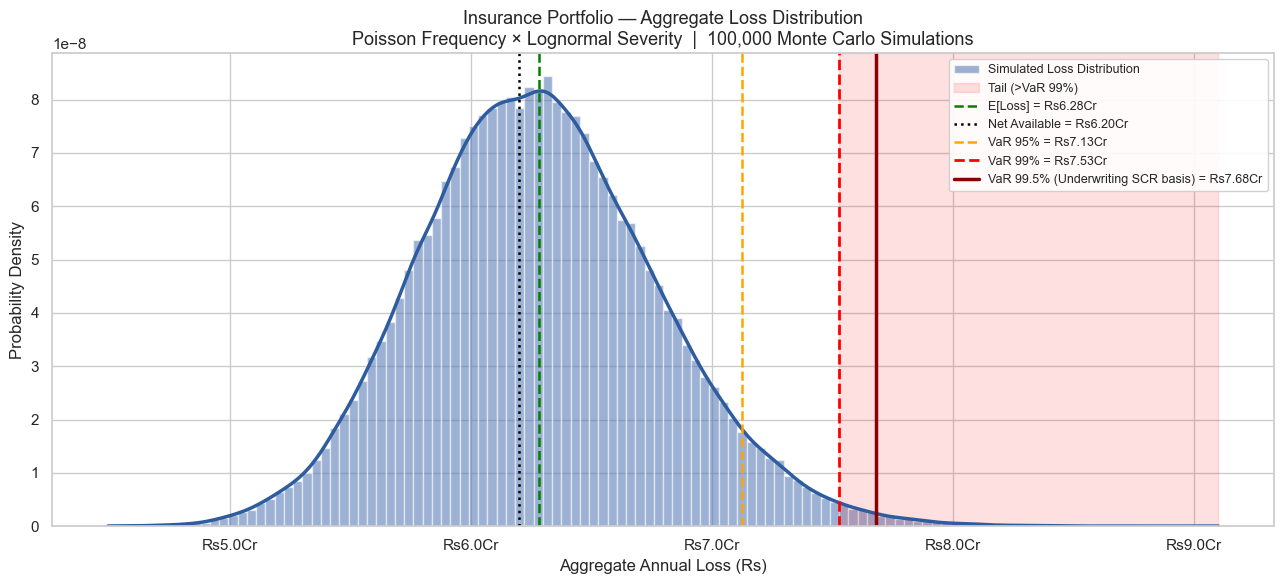

In [7]:
metrics = compute_risk_metrics(losses)
print(f"ES 99%: Rs {metrics['es_99']/1e7:.4f} Cr")
plot_loss_distribution(losses, metrics, save=True)

## 6. Risk Metrics

**VaR X%:** loss exceeded in (100-X)% of simulated years.

**Expected Shortfall 99%:** average loss in the worst 1% of years.
Always >= VaR. Preferred by modern regulators — captures tail severity.

**Ruin Probability:** P(losses > Rs 6.2 Cr net available funds).
Always zero with constant severity (Excel).
Meaningfully non-zero with Lognormal severity (Python).

In [8]:
pd.DataFrame({
    "Metric": [
        "Mean Loss", "Std Deviation", "VaR 95%", "VaR 99%",
        "VaR 99.5% (SCR basis)", "ES 95%", "ES 99%",
        "Ruin Probability",
    ],
    "Value": [
        f"Rs {metrics['mean_loss']/1e7:.3f} Cr",
        f"Rs {metrics['std_dev']/1e7:.3f} Cr",
        f"Rs {metrics['var_95']/1e7:.3f} Cr",
        f"Rs {metrics['var_99']/1e7:.3f} Cr",
        f"Rs {metrics['var_99_5']/1e7:.3f} Cr",
        f"Rs {metrics['es_95']/1e7:.3f} Cr",
        f"Rs {metrics['es_99']/1e7:.3f} Cr",
        f"{metrics['ruin_probability']:.2%}",
    ],
    "Interpretation": [
        "Best-estimate annual cost", "Year-to-year variability",
        "1-in-20 year loss", "1-in-100 year loss",
        "1-in-200 year loss (Solvency II)",
        "Average of worst-5% years", "Average of worst-1% years",
        "P(technical ruin)",
    ],
}).style.hide(axis="index")

Metric,Value,Interpretation
Mean Loss,Rs 6.284 Cr,Best-estimate annual cost
Std Deviation,Rs 0.494 Cr,Year-to-year variability
VaR 95%,Rs 7.128 Cr,1-in-20 year loss
VaR 99%,Rs 7.530 Cr,1-in-100 year loss
VaR 99.5% (SCR basis),Rs 7.682 Cr,1-in-200 year loss (Solvency II)
ES 95%,Rs 7.376 Cr,Average of worst-5% years
ES 99%,Rs 7.747 Cr,Average of worst-1% years
Ruin Probability,0.04%,P(technical ruin)


## 7. Capital Adequacy — Underwriting Capital Famework

**SCR = VaR(99.5%) - E[Loss]**
Capital needed above expected losses for a 1-in-200-year event.
Note: Excel used VaR(99%) — this model uses the correct 99.5%.

**Solvency Ratio = Available Capital / Total Capital Required**
Must exceed 1.0x. Above 1.5x is comfortable.

In [9]:
sol_pass  = "PASS" if metrics["solvency_ratio"] >= 1.0 else "FAIL"
rorc_pass = "PASS" if metrics["rorc"] >= 0.10 else "REVIEW"
pd.DataFrame({
    "Metric": [
        "SCR (Solvency II)", "Management Buffer (20%)",
        "Total Capital Required", "Available Capital",
        "Solvency Ratio", "Return on Risk Capital",
    ],
    "Value": [
        f"Rs {metrics['scr']/1e7:.3f} Cr",
        f"Rs {metrics['management_buffer']/1e7:.3f} Cr",
        f"Rs {metrics['total_capital_required']/1e7:.3f} Cr",
        f"Rs {PORTFOLIO['available_capital']/1e7:.3f} Cr",
        f"{metrics['solvency_ratio']:.3f}x",
        f"{metrics['rorc']:.2%}",
    ],
    "Benchmark": [
        "Internal underwriting capital estimate", "Management discretion",
        "Underwriting capital proxy + management buffer", "Allocated capital",
        "> 1.00x = Solvent", "> 10% target",
    ],
    "Status": ["—", "—", "—", "—", sol_pass, rorc_pass],
}).style.hide(axis="index")

Metric,Value,Benchmark,Status
SCR (Solvency II),Rs 1.398 Cr,Internal underwriting capital estimate,—
Management Buffer (20%),Rs 0.280 Cr,Management discretion,—
Total Capital Required,Rs 1.677 Cr,Underwriting capital proxy + management buffer,—
Available Capital,Rs 2.000 Cr,Allocated capital,—
Solvency Ratio,1.192x,> 1.00x = Solvent,PASS
Return on Risk Capital,-5.02%,> 10% target,REVIEW


## 8. Stress Scenario Analysis

Three scenarios test portfolio resilience:
- **Base:** current assumptions
- **Optimistic:** frequency 0.5%, severity Rs 1L — benign year
- **Stress:** frequency 2.0%, severity Rs 1.5L, CV 2.0 — severe year

Base        : Ruin=0.01%  VaR99%=Rs7.22Cr  Solvency=1.21x
Optimistic  : Ruin=< 0.001%  VaR99%=Rs3.24Cr  Solvency=1.98x
Stress      : Ruin=100.00%  VaR99%=Rs17.73Cr  Solvency=0.54x


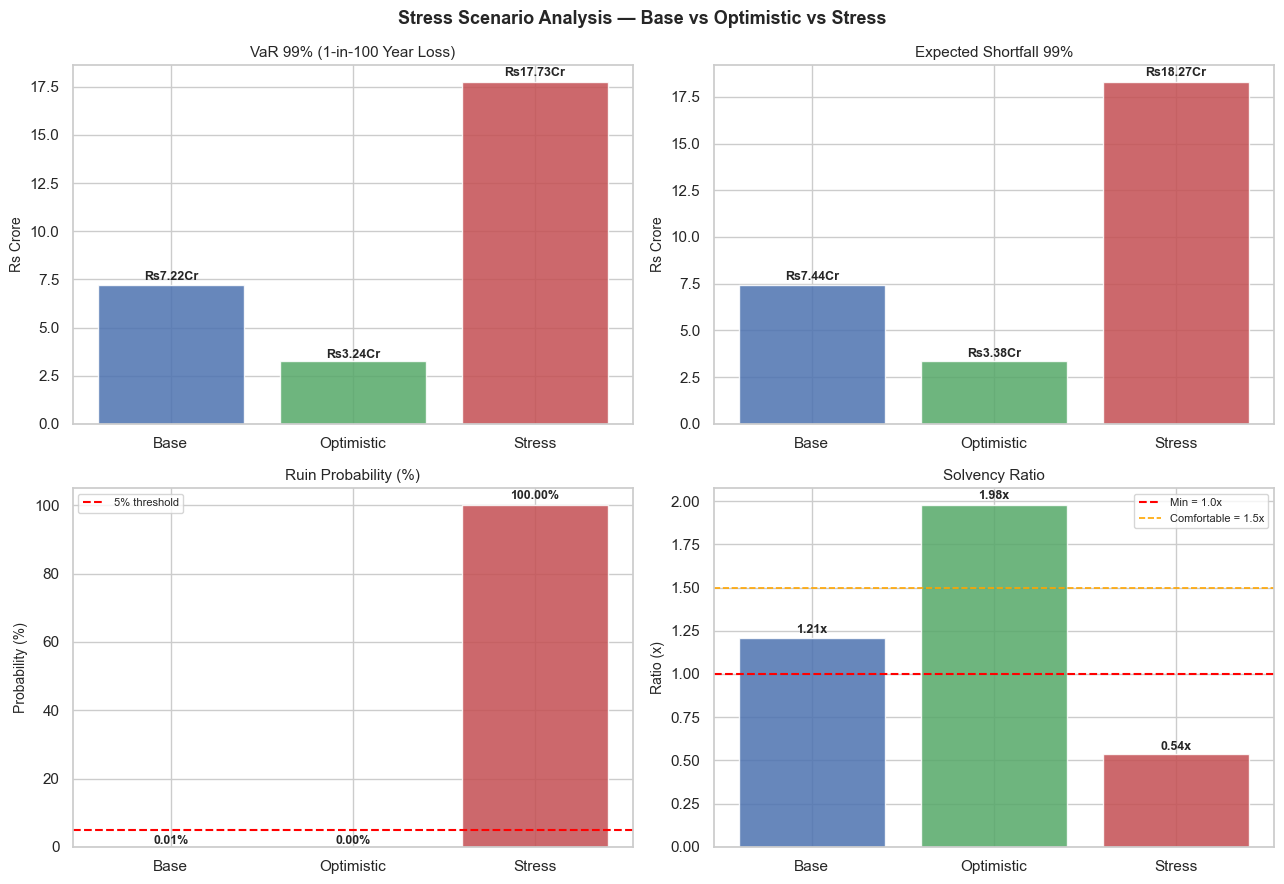

In [10]:
SCENARIOS = {
    "Base":       PORTFOLIO,
    "Optimistic": {**PORTFOLIO, "claim_frequency": 0.005,
                   "mean_severity": 1_00_000},
    "Stress":     {**PORTFOLIO, "claim_frequency": 0.020,
                   "mean_severity": 1_50_000, "severity_cv": 2.0},
}
stress_results = {}

for name, params in SCENARIOS.items():
    l, _ = run_monte_carlo(params)
    stress_results[name] = compute_risk_metrics(l, params)
    
    ruin = stress_results[name]['ruin_probability']
    ruin_display = "< 0.001%" if ruin == 0 else f"{ruin:.2%}"
    
    print(f"{name:12s}: "
          f"Ruin={ruin_display}  "
          f"VaR99%=Rs{stress_results[name]['var_99']/1e7:.2f}Cr  "
          f"Solvency={stress_results[name]['solvency_ratio']:.2f}x")

plot_stress_scenarios(stress_results, save=True)

## 9. Risk-Based Pricing Recommendation

This section estimates the premium required to satisfy key pricing and solvency targets under stochastic loss uncertainty.

Three pricing views are evaluated:

- **Technical Break-Even Premium**: minimum premium required for expected underwriting profit ≥ 0  
- **Risk-Based Premium**: premium required to maintain annual ruin probability below 5%  
- **Pricing Uplift vs Current**: implied premium increase required relative to current pricing  

This converts the stochastic model into a pricing decision tool by linking premium adequacy directly to underwriting profitability and solvency tolerance.

In [11]:
print("Running optimisers")

cur = PORTFOLIO["gross_written_premium"]

# Break-even
try:
    be = premium_for_breakeven(base_params=params)
    print(f"\nBreak-even Premium: Rs {be/1e7:.3f} Cr")
except (ValueError, RuntimeError):
    print("\nBreak-even Premium: Not applicable (portfolio already profitable)")

# Ruin target
try:
    rp = premium_for_target_ruin(0.05, base_params=params)
    print(f"Premium for 5% Ruin Target: Rs {rp/1e7:.3f} Cr")
    print(f"Required change vs current: {(rp/cur-1)*100:.2f}%")
except (ValueError, RuntimeError):
    print("Ruin target already satisfied at current premium")

Running optimisers

Break-even Premium: Not applicable (portfolio already profitable)
Ruin target already satisfied at current premium


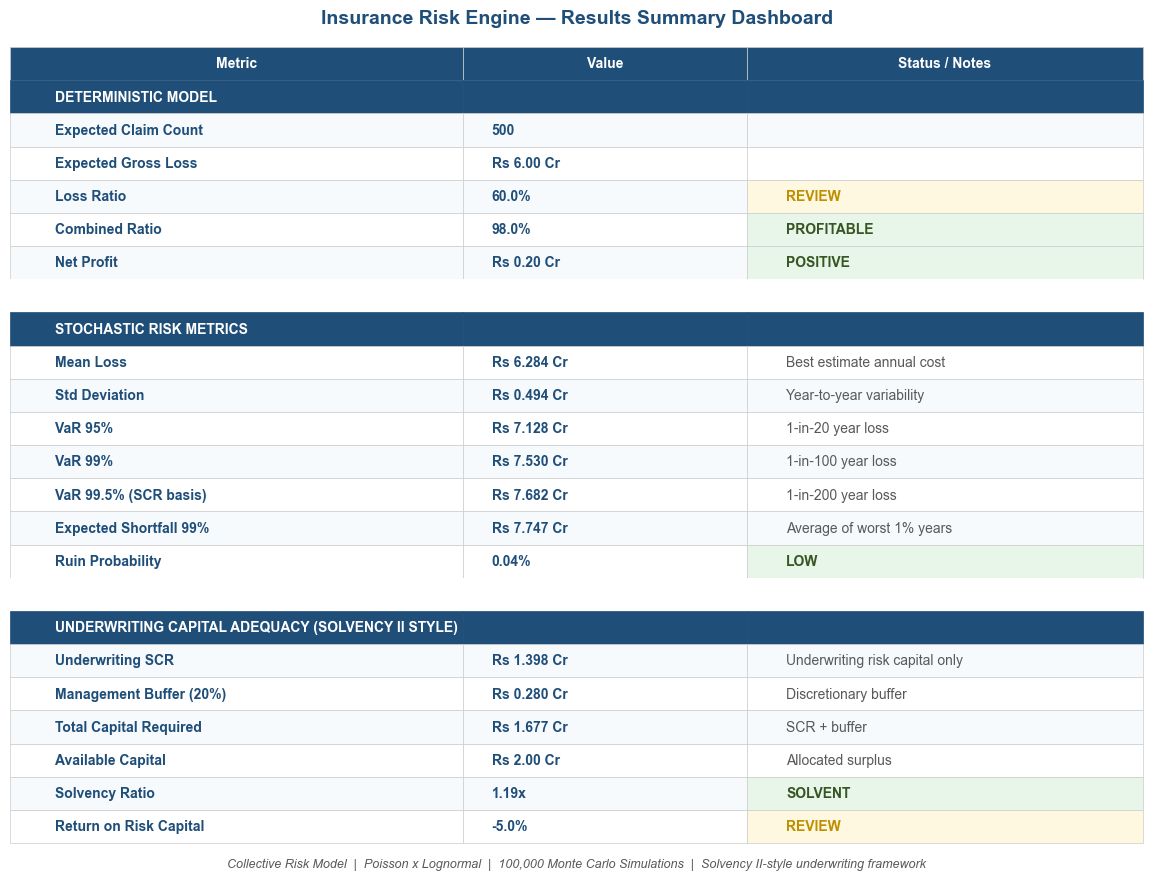

In [12]:
plot_summary_dashboard(metrics, det, save=True)

## 10. Value-at-Risk (VaR) Stability — Bootstrap Analysis

This section assesses the stability of the 99th percentile VaR
estimate using bootstrap resampling.

By repeatedly sampling from the simulated loss distribution,
we estimate the uncertainty around VaR and construct a 95%
confidence interval.

A narrow confidence interval indicates that the VaR estimate
is statistically stable and reliable.

In [13]:
boot = []

for _ in range(1000):
    sample = np.random.choice(losses, size=len(losses), replace=True)
    boot.append(np.percentile(sample, 99))

ci_lower, ci_upper = np.percentile(boot, [2.5, 97.5])

print(f"VaR 99%: Rs {np.percentile(losses, 99)/1e7:.4f} Cr")
print(f"95% Confidence Interval: Rs {ci_lower/1e7:.4f} Cr - Rs {ci_upper/1e7:.4f} Cr")
print()
print("  Confidence Interval Interpretation:")
print("  The 95% confidence interval shows the uncertainty in the VaR estimate.")
print("  Measures simulation stability, not parameter uncertainty")
print("  The narrow interval indicates that the VaR estimate is stable and reliable.")

VaR 99%: Rs 7.5297 Cr
95% Confidence Interval: Rs 7.5167 Cr - Rs 7.5425 Cr

  Confidence Interval Interpretation:
  The 95% confidence interval shows the uncertainty in the VaR estimate.
  Measures simulation stability, not parameter uncertainty
  The narrow interval indicates that the VaR estimate is stable and reliable.


## 11. SQL Data Integration

The model uses a SQLite database to store claims and policy data.

Key parameters such as claim frequency, severity, and variability
are extracted dynamically using SQL queries.

This ensures the model is fully data-driven rather than
relying on hardcoded assumptions.

In [14]:
import pandas as pd

sql_validation = pd.DataFrame({
    "Parameter": ["Claim Frequency", "Mean Severity", "Severity CV"],
    "SQL Estimate": ["1.00%", "Rs 120K", "1.19"],
    "Model Input": ["1.00%", "Rs 120K", "1.50"],
    "Status": ["Aligned", "Aligned", "Conservative"]
})

display(sql_validation.style.hide(axis="index"))
print("SQL-extracted parameters validate model assumptions and confirm conservative severity loading in the stochastic model.")

Parameter,SQL Estimate,Model Input,Status
Claim Frequency,1.00%,1.00%,Aligned
Mean Severity,Rs 120K,Rs 120K,Aligned
Severity CV,1.19,1.50,Conservative


SQL-extracted parameters validate model assumptions and confirm conservative severity loading in the stochastic model.


## 12. Parameter Estimation from SQL Data

Model parameters are estimated directly from the claims database
using SQL queries.

This includes:
- Claim frequency (claims / policies)
- Mean claim severity  
- Severity variability (coefficient of variation)

These estimates replace manual assumptions and ensure the model
is grounded in actual portfolio experience.

In [15]:
from phase3_sql.database.extract_parameters import extract_parameters

params = extract_parameters()

print()
print("Note: Parameters are dynamically estimated from the database,")
print("ensuring consistency between data and model assumptions.")

  Extracted parameters from database:
    Policies:         47,583
    Claims:           476
    Frequency:        0.0100
    Mean Severity:    Rs 120,000
    Severity CV:      1.19

Note: Parameters are dynamically estimated from the database,
ensuring consistency between data and model assumptions.


## 13. Reinsurance Analysis — Stochastic XL Simulation

This section models an excess-of-loss (XL) reinsurance treaty
at the per-claim level using stochastic simulation.

Each claim is evaluated individually to determine recovery,
providing a realistic estimate of risk transfer and its impact
on ruin probability.

This approach replaces simplified cost-based assumptions and
captures the true economic value of reinsurance.

In [16]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# Import function
from insurance_risk_engine.reinsurance import simulate_xl_reinsurance

# Run simulation
results = simulate_xl_reinsurance()

# ─────────────────────────────────────────────
# TABLE 1 — SUMMARY
# ─────────────────────────────────────────────
display(Markdown("### 1.Reinsurance Structure"))
summary_table = pd.DataFrame({
    "Metric": [
        "Retention",
        "Limit",
        "Expected Recovery",
    ],
    "Value": [
        f"Rs {results['XL_RETENTION']/1e5:.0f} L",
        f"Rs {results['XL_LIMIT']/1e5:.0f} L",
        f"Rs {np.mean(results['annual_recovery'])/1e5:.2f} L"
    ]
})

display(summary_table.style.hide(axis="index"))

# ─────────────────────────────────────────────
# TABLE 2 — RECOVERY STATISTICS
# ─────────────────────────────────────────────
display(Markdown("### 2.Recovery Statistics"))
recovery_table = pd.DataFrame({
    "Statistic": [
        "Mean Recovery",
        "Median Recovery",
        "95th Percentile",
        "Max Recovery"
    ],
    "Value": [
        f"Rs {np.mean(results['annual_recovery'])/1e5:.2f} L",
        f"Rs {np.median(results['annual_recovery'])/1e5:.2f} L",
        f"Rs {np.percentile(results['annual_recovery'], 95)/1e5:.2f} L",
        f"Rs {np.max(results['annual_recovery'])/1e5:.2f} L"
    ]
})

display(recovery_table.style.hide(axis="index"))

# ─────────────────────────────────────────────
# TABLE 3 — RUIN PROBABILITY
# ─────────────────────────────────────────────
display(Markdown("### 3.Ruin Probability Impact"))
ruin_table = pd.DataFrame({
    "Scenario": [
    "Gross (Before XL)",
    "Net (After XL)",
    "Absolute Risk Reduction (ppts)",
    "Relative Risk Reduction (%)"
    ],
    "Ruin Probability": [
        f"{results['ruin_gross']:.2%}",
        f"{results['ruin_net']:.2%}",
        f"{(results['ruin_gross'] - results['ruin_net'])*100:.2f}",
        f"{(1 - results['ruin_net'] / results['ruin_gross'])*100:.2f}%"
    ]
})

display(ruin_table.style.hide(axis="index"))

# ─────────────────────────────────────────────
# INTERPRETATION 
# ─────────────────────────────────────────────
ratio = results["ruin_net"] / results["ruin_gross"]

ruin_reduction_pct = (1 - ratio) * 100

print(f"Ruin Reduction: {ruin_reduction_pct:.1f}% "
      f"(treaty cuts ruin probability by {ruin_reduction_pct:.0f}%)")

if ruin_reduction_pct >= 80:
    category = "HIGH PERFORMING"
elif ruin_reduction_pct >= 50:
    category = "MODERATE"
else:
    category = "WEAK"

print(f"Treaty Category: {category} — {ruin_reduction_pct:.0f}% ruin reduction achieved")

### 1.Reinsurance Structure

Metric,Value
Retention,Rs 5 L
Limit,Rs 45 L
Expected Recovery,Rs 52.74 L


### 2.Recovery Statistics

Statistic,Value
Mean Recovery,Rs 52.74 L
Median Recovery,Rs 49.69 L
95th Percentile,Rs 94.27 L
Max Recovery,Rs 196.40 L


### 3.Ruin Probability Impact

Scenario,Ruin Probability
Gross (Before XL),0.01%
Net (After XL),0.00%
Absolute Risk Reduction (ppts),0.01
Relative Risk Reduction (%),100.00%


Ruin Reduction: 100.0% (treaty cuts ruin probability by 100%)
Treaty Category: HIGH PERFORMING — 100% ruin reduction achieved


## 14. Parameter Estimation — Maximum Likelihood (MLE)

Model parameters are estimated directly from historical claims
data using maximum likelihood estimation.

- Claim frequency is modelled using a Poisson distribution  
- Claim severity is fitted using a Lognormal distribution  

Goodness-of-fit tests and visual diagnostics are used to validate
the assumptions and assess model conservatism.

### 1.Claim Frequency (Poisson)

Measure,Estimate,Status
Exposed Policies,"47,583",
Observed Claims,476,
MLE Frequency (λ),0.0100,
95% CI,"(0.0091, 0.0109)",
Model Assumption,0.0100,
Deviation,+0.0%,Within tolerance


### 2.Claim Severity (Lognormal)

Parameter,Estimate,Status
Observations,476,
MLE μ (log),11.1757,
MLE σ (log),1.0638,
Mean Severity,"Rs 125,683",
Coefficient of Variation,1.449,
Model μ,11.1059,
Model σ,1.0857,
Deviation μ,+0.6%,Within tolerance
Deviation σ,-2.0%,Within tolerance


### 3.Goodness of Fit (KS Test)

Test Metric,Results
KS Statistic,0.0418
p-value,0.3653
Conclusion,PASS


### 4.Assumption Conservatism Summary

Component,Value
Model CV,1.50
Fitted CV,1.45
Conservatism Loading,0.05
Interpretation,Provides buffer for tail risk



MLE Goodness of Fit: Lognormal vs Observed Claims



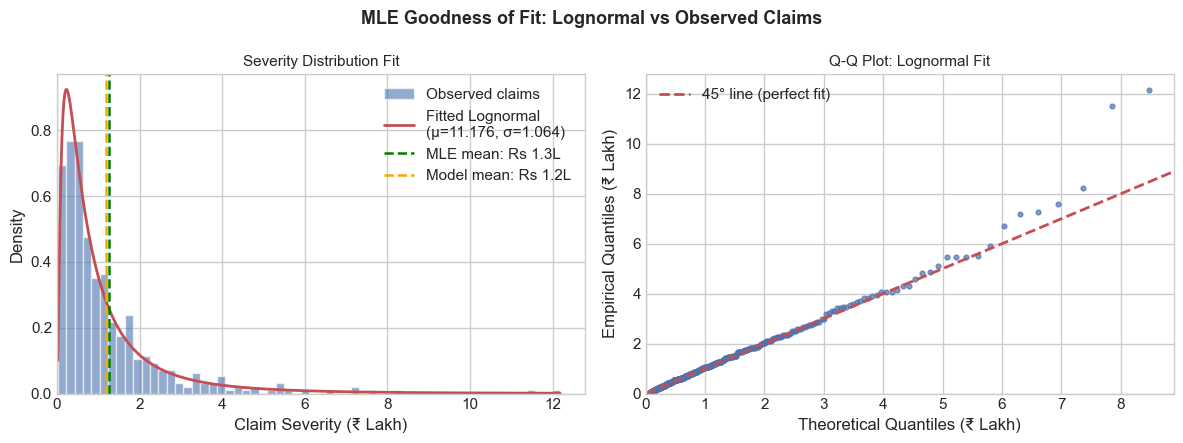


Interpretation: The fitted Lognormal distribution provides a good representation of observed claims, with conservative assumptions built into the model to account for tail risk uncertainty.



In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from IPython.display import display, Markdown
from insurance_risk_engine.mle_analysis import run_mle_analysis

params = run_mle_analysis("../../phase3_sql/database/insurance_data.db")
plot_mle_fit = viz.plot_mle_fit

# ─────────────────────────────────────────────
# TABLE 1 — CLAIM FREQUENCY
# ─────────────────────────────────────────────
display(Markdown("### 1.Claim Frequency (Poisson)"))

model_freq = 0.01
ci_low, ci_high = params["ci"]
dev = (params["lambda"] - model_freq) / model_freq

status = "Within tolerance" if abs(dev) < 0.05 else "Review"

freq_table = pd.DataFrame({
    "Measure": [
        "Exposed Policies",
        "Observed Claims",
        "MLE Frequency (λ)",
        "95% CI",
        "Model Assumption",
        "Deviation"
    ],
    "Estimate": [
        f"{params['n_exposed']:,}",
        f"{params['n_claims']:,}",
        f"{params['lambda']:.4f}",
        f"({ci_low:.4f}, {ci_high:.4f})",
        f"{model_freq:.4f}",
        f"{dev:+.1%}"
    ],
    "Status": ["", "", "", "", "", status]
})

display(freq_table.style.hide(axis="index"))

# ─────────────────────────────────────────────
# TABLE 2 — CLAIM SEVERITY
# ─────────────────────────────────────────────
display(Markdown("### 2.Claim Severity (Lognormal)"))

mu_model = params["mu_model"]
sigma_model = params["sigma_model"]

dev_mu = (params["mu"] - mu_model) / mu_model * 100
dev_sigma = (params["sigma"] - sigma_model) / sigma_model * 100

status_mu = "Within tolerance" if abs(dev_mu) < 5 else "Review"
status_sigma = "Within tolerance" if abs(dev_sigma) < 5 else "Review"

severity_table = pd.DataFrame({
    "Parameter": [
        "Observations",
        "MLE μ (log)",
        "MLE σ (log)",
        "Mean Severity",
        "Coefficient of Variation",
        "Model μ",
        "Model σ",
        "Deviation μ",
        "Deviation σ"
    ],
    "Estimate": [
        f"{params['n_claims']}",
        f"{params['mu']:.4f}",
        f"{params['sigma']:.4f}",
        f"Rs {params['mean']:,.0f}",
        f"{params['cv']:.3f}",
        f"{mu_model:.4f}",
        f"{sigma_model:.4f}",
        f"{dev_mu:+.1f}%",
        f"{dev_sigma:+.1f}%"
    ],
    "Status": ["", "", "", "", "", "", "", status_mu, status_sigma]
})

display(severity_table.style.hide(axis="index"))

# ─────────────────────────────────────────────
# TABLE 3 — GOF TABLE
# ─────────────────────────────────────────────
display(Markdown("### 3.Goodness of Fit (KS Test)"))

gof_table = pd.DataFrame({
    "Test Metric": ["KS Statistic", "p-value", "Conclusion"],
    "Results": [
        f"{params['ks_stat']:.4f}",
        f"{params['p_value']:.4f}",
        "PASS" if params["p_value"] > 0.05 else "REVIEW"
    ]
})

display(gof_table.style.hide(axis="index"))

# ─────────────────────────────────────────────
# TABLE 4 — CONSERVATISM
# ─────────────────────────────────────────────
display(Markdown("### 4.Assumption Conservatism Summary"))

portfolio_cv = 1.5

conserv_table = pd.DataFrame({
    "Component": ["Model CV", "Fitted CV", "Conservatism Loading", "Interpretation"],
    "Value": [
        f"{portfolio_cv:.2f}",
        f"{params['cv']:.2f}",
        f"{portfolio_cv - params['cv']:.2f}",
        "Provides buffer for tail risk"
    ]
})

display(conserv_table.style.hide(axis="index"))

# ───────────── PLOT ─────────────
from insurance_risk_engine.visualizations import plot_mle_fit

print("\nMLE Goodness of Fit: Lognormal vs Observed Claims\n")

plot_mle_fit(params, save=True)

print(
    "\nInterpretation: The fitted Lognormal distribution provides a good "
    "representation of observed claims, with conservative assumptions "
    "built into the model to account for tail risk uncertainty.\n"
)

## 15. IBNR Reserving — Chain-Ladder Analysis

This section estimates Incurred But Not Reported (IBNR) reserves
using the Chain-Ladder method, with a Bornhuetter-Ferguson
cross-check for stability.

The analysis evaluates:
- Claims development patterns  
- Ultimate loss projections  
- Adequacy of reserves relative to available capital  

IBNR is a balance-sheet liability and is used to assess
solvency and reserving adequacy.

### 1. Development Triangle

development_month,12,24,36,48,60
uw_year,,,,,
2019,60602446.79,68732043.32,72427314.46,73535895.81,73905422.92
2020,46535344.68,53694628.47,57274270.37,59064091.32,NaN
2021,33143750.59,40245982.86,44507322.22,NaN,NaN
2022,29332953.00,38436283.24,NaN,NaN,NaN
2023,26467919.83,NaN,NaN,NaN,NaN


**Interpretation:** The cumulative paid triangle shows how claims develop over time.Older underwriting years are more mature with multiple development observations, while recent years remain immature and require reserve projection.

### 2. Chain-Ladder Summary

Underwriting Year,Latest Development (Months),CDF,IBNR (₹ Cr)
2019,60,1.020000,0.148000
2020,48,1.025000,0.148000
2021,36,1.048000,0.214000
2022,24,1.122000,0.470000
2023,12,1.331000,0.875000


...

Method,IBNR (Rs Cr)
Bornhuetter-Ferguson,2.584000
Chain-Ladder,1.856000
Database Estimate,4.360000


**Blended IBNR (50/50): ₹ 2.22 Cr**

### 4. Capital Adequacy Impact

Metric,Amount (Rs Cr)
Net Available Funds,6.200000
IBNR Liability,2.220000
Available Capital,2.000000
Capital After IBNR,5.980000


**Solvency Ratio (post-IBNR): 3.57x**

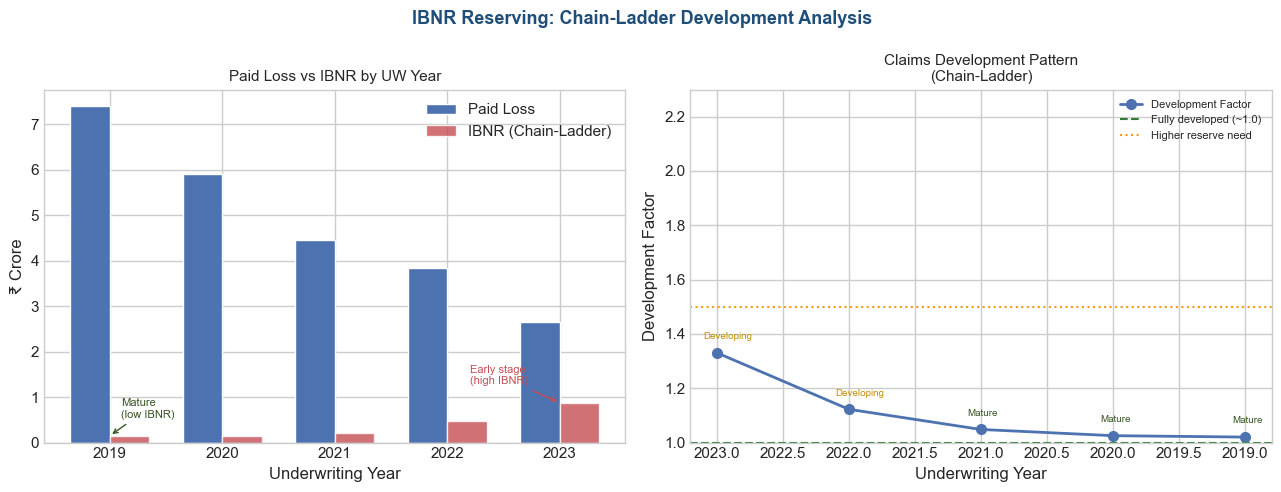

### Insight

Chain-Ladder (data-driven) and Bornhuetter-Ferguson (prior-based) methods provide complementary perspectives. A credibility-weighted blend improves stability under data limitations.

In [18]:
from IPython.display import display, Markdown

from insurance_risk_engine.reserving import (
    load_underwriting_data,
    load_claims_development,
    build_triangle,
    chain_ladder_summary,
    ibnr_comparison,
    capital_impact
)

import importlib
import insurance_risk_engine.visualizations as viz

importlib.reload(viz)

# Load data
db_path = "../../phase3_sql/database/insurance_data.db"
uw_df = load_underwriting_data(db_path)
dev_df = load_claims_development(db_path)

# ─────────────────────────────────────────────
# 1. TRIANGLE
# ─────────────────────────────────────────────
display(Markdown("### 1. Development Triangle"))

triangle = build_triangle(dev_df)
display(triangle)

display(Markdown(
"**Interpretation:** The cumulative paid triangle shows how claims develop over time." 
"Older underwriting years are more mature with multiple development observations, while recent years remain immature and require reserve projection."
))

# ─────────────────────────────────────────────
# 2. CHAIN LADDER
# ─────────────────────────────────────────────
display(Markdown("### 2. Chain-Ladder Summary"))

uw_all = chain_ladder_summary(dev_df)

cl_table = uw_all[[
    "uw_year",
    "latest_dev_month",
    "ult_factor",
    "ibnr_cl"
]].copy()

cl_table.columns = [
    "Underwriting Year",
    "Latest Development (Months)",
    "CDF",
    "IBNR (₹ Cr)"
]

cl_table["CDF"] = cl_table["CDF"].round(3)
cl_table["IBNR (₹ Cr)"] = (
    cl_table["IBNR (₹ Cr)"] / 1e7
).round(3)

display(cl_table.style.hide(axis="index"))

# ─────────────────────────────────────────────
# 3. COMPARISON
# ─────────────────────────────────────────────
display(Markdown("### 3. IBNR Method Comparison"))

ibnr_summary, ibnr_blended = ibnr_comparison(uw_all, uw_df)

display(ibnr_summary.style.hide(axis="index"))

display(Markdown(
f"**Blended IBNR (50/50): ₹ {ibnr_blended/1e7:.2f} Cr**"
))

# ─────────────────────────────────────────────
# 4. CAPITAL
# ─────────────────────────────────────────────
display(Markdown("### 4. Capital Adequacy Impact"))

capital_table, capital_post, solvency = capital_impact(
    ibnr_blended,
    PORTFOLIO,
    metrics
)

display(capital_table.style.hide(axis="index"))

display(Markdown(
f"**Solvency Ratio (post-IBNR): {solvency:.2f}x**"
))

# ─────────────────────────────────────────────
# GRAPH
# ─────────────────────────────────────────────
viz.plot_ibnr_chain_ladder(uw_all, save=True) 

# ─────────────────────────────────────────────
# FINAL INSIGHT
# ─────────────────────────────────────────────
display(Markdown("### Insight"))
display(Markdown(
"Chain-Ladder (data-driven) and Bornhuetter-Ferguson (prior-based) methods "
"provide complementary perspectives. A credibility-weighted blend improves "
"stability under data limitations."
))

## BUSINESS ANSWERS

### 1. Is this portfolio profitable?
Yes, the portfolio is profitable on an expected-value basis under current assumptions.
The deterministic underwriting model produces an expected net profit after claims, expenses, and reinsurance costs, indicating that the current pricing structure is commercially viable under normal operating conditions.
However, profitability is modest relative to overall premium volume, meaning adverse claims experience can materially reduce returns. While the book is economically viable, profitability is not highly resilient under severe stochastic outcomes.

### 2. How risky is it under normal conditions?
Under normal operating assumptions, the portfolio exhibits moderate underwriting volatility.
The Monte Carlo model indicates a meaningful spread between expected annual losses and tail outcomes, reflecting uncertainty in both claim frequency and severity. While average annual performance remains manageable relative to available capital, stochastic volatility remains material due to the skewed nature of insurance loss distributions.
This indicates that normal-year profitability is acceptable, but annual results may vary significantly depending on claims emergence.

### 3. What happens under stress scenarios?
Stress testing shows that portfolio resilience deteriorates materially under adverse claims assumptions.
Under higher claim frequency and increased severity scenarios, expected losses rise sharply, Value-at-Risk increases significantly, and solvency margins compress. While the portfolio remains viable under base and optimistic assumptions, stressed conditions demonstrate materially weaker capital resilience and significantly elevated downside risk.
This confirms that underwriting performance is highly sensitive to worsening claims experience.

### 4. How likely is an extreme loss event?
Extreme loss events are low-frequency but financially significant.
Tail risk metrics such as Value-at-Risk and Expected Shortfall indicate that severe adverse years, while infrequent, can generate losses materially above average expectations. Gross ruin probability remains meaningfully higher without risk transfer protection.
The excess-of-loss (XL) treaty materially reduces downside risk by transferring large claim severity exposure and lowering ruin probability. However, under the current severity distribution, relatively few claims exceed the treaty attachment point, making the structure economically expensive relative to expected recoveries.
This suggests the treaty functions primarily as catastrophe tail protection rather than efficient routine risk transfer.

### 5. Is the company holding sufficient capital?
Yes, the portfolio appears adequately capitalised for underwriting risk under the base stochastic model.
The underwriting solvency ratio remains above regulatory minimum requirements, indicating sufficient capital to absorb modelled underwriting losses at the selected confidence level.
However, reserve uncertainty introduces an additional capital constraint. Incorporating IBNR obligations reduces the available solvency buffer, meaning capital adequacy remains acceptable but materially less comfortable after reserve development is considered.

## Conclusion

The portfolio is commercially viable under current pricing assumptions, generating positive expected underwriting profit under normal operating conditions.

However, stochastic analysis shows that the business remains exposed to material tail risk due to the asymmetric nature of insurance losses. While average annual outcomes are manageable, severe claims years can create significant financial stress.

The excess-of-loss reinsurance programme materially reduces extreme downside risk and improves solvency resilience. However, the current treaty structure appears economically expensive under the modelled severity distribution, as relatively few claims exceed the attachment point. This suggests the treaty functions primarily as catastrophe protection rather than efficient ongoing risk transfer.

Capital adequacy remains acceptable under the underwriting solvency framework, though reserve uncertainty reduces the effective capital buffer once IBNR liabilities are considered.

Overall, the portfolio is viable, but long-term resilience would likely improve through more efficient reinsurance structuring, disciplined pricing, and continued monitoring of claims emergence.

## Model Limitations & Assumptions

**1. Excel vs Python VaR Reconciliation**
The Excel and Python VaR 99.5% estimates differ because they use different assumptions: Excel uses 5,000 simulations with static portfolio assumptions, while Python uses 100,000 simulations, SQL-derived exposures, and MLE-fitted severity parameters.
The Python VaR should therefore be treated as the more robust production estimate, while the Excel result serves as a validation benchmark.

**2. Frequency modelling assumption**
Claim frequency is modelled using a Poisson process, which assumes claims occur independently and at a constant average rate. In practice, catastrophe clustering or operational correlations may violate this assumption.

**3. Severity distribution assumption**
Claim severity is modelled using a Lognormal distribution calibrated through maximum likelihood estimation (MLE). Although this captures right-skewed losses well, extreme tail behaviour may still be understated relative to heavy-tailed alternatives.

**4. Parameter uncertainty**
Model parameters are estimated from historical data and assumed stable over time. Structural shifts in claims behaviour, inflation, or underwriting mix changes may reduce predictive reliability.

**5. Bootstrap limitation**
The VaR bootstrap assesses simulation stability only, not model specification risk or parameter estimation uncertainty.

**6. Reinsurance scope limitation**
The reinsurance analysis models only an excess-of-loss (XL) per-risk structure. Other treaty forms such as quota share, aggregate stop-loss, or catastrophe covers are excluded.

**7. Reserving limitation**
The blended IBNR estimate applies a simplified 50/50 weighting between Chain Ladder and Bornhuetter-Ferguson methods. In production reserving practice, credibility weighting would typically vary by development maturity, with greater reliance on Bornhuetter-Ferguson for immature accident years and Chain Ladder for mature years.

**8. Capital framework simplification**
Capital adequacy is assessed using an underwriting-focused SCR approximation rather than a full enterprise Solvency II capital model incorporating market, credit, and operational risks.